In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("1774598598573_40ac5dfaa3.csv")
df.head()

,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit
0,2022-06-20,UAE,Dubai,Furniture,Snacks,Consumer,Offline,UPI,2555.49,11,0.08,255.37
1,2023-12-05,UK,London,Sports,Phones,Home Office,Online,Net Banking,1795.27,9,0.28,-332.23
2,2022-07-05,USA,Los Angeles,Electronics,Shirts,Consumer,Offline,UPI,4554.73,10,0.13,140.24
3,2024-10-05,USA,New York,Furniture,Phones,Consumer,Online,Net Banking,3107.15,13,0.14,60.70
4,2023-07-21,USA,New York,Beauty,Fitness,Consumer,Offline,Card,2781.45,12,0.20,61.78


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

Shape: (1600, 12)

Columns:
['Order_Date', 'Country', 'City', 'Category', 'Sub_Category', 'Segment', 'Sales_Channel', 'Payment_Mode', 'Sales', 'Quantity', 'Discount', 'Profit']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_Date     1600 non-null   object 
 1   Country        1600 non-null   object 
 2   City           1600 non-null   object 
 3   Category       1600 non-null   object 
 4   Sub_Category   1600 non-null   object 
 5   Segment        1600 non-null   object 
 6   Sales_Channel  1600 non-null   object 
 7   Payment_Mode   1600 non-null   object 
 8   Sales          1600 non-null   float64
 9   Quantity       1600 non-null   int64  
 10  Discount       1600 non-null   float64
 11  Profit         1600 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 150.1+ KB


In [4]:
df.describe(include="all")

,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit
count,1600,1600,1600,1600,1600,1600,1600,1600,1600.000000,1600.000000,1600.000000,1600.000000
unique,963,8,24,6,6,3,2,4,NaN,NaN,NaN,NaN
top,2023-12-09,India,Mumbai,Electronics,Chairs,Home Office,Offline,Card,NaN,NaN,NaN,NaN
freq,6,227,89,288,295,546,817,438,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2527.242200,7.582500,0.147138,244.332881
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1410.954469,3.999618,0.085156,515.339896
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.260000,1.000000,0.000000,-937.750000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1293.730000,4.000000,0.070000,-88.145000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2496.750000,8.000000,0.150000,138.665000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3715.987500,11.000000,0.220000,535.817500


In [5]:
print("Missing values:\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:

Order_Date       0
Country          0
City             0
Category         0
Sub_Category     0
Segment          0
Sales_Channel    0
Payment_Mode     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


The dataset is clean, with no missing values or duplicate records, indicating high data quality.




In [6]:
df.describe()


,Sales,Quantity,Discount,Profit
count,1600.000000,1600.000000,1600.000000,1600.000000
mean,2527.242200,7.582500,0.147138,244.332881
std,1410.954469,3.999618,0.085156,515.339896
min,100.260000,1.000000,0.000000,-937.750000
25%,1293.730000,4.000000,0.070000,-88.145000
50%,2496.750000,8.000000,0.150000,138.665000
75%,3715.987500,11.000000,0.220000,535.817500
max,4996.120000,14.000000,0.300000,1921.420000


Next we check for unique values

In [7]:
print("Categories:", df["Category"].unique())
print("\nCountries:", df["Country"].unique())
print("\nSegments:", df["Segment"].unique())

Categories: ['Furniture' 'Sports' 'Electronics' 'Beauty' 'Groceries' 'Clothing']

Countries: ['UAE' 'UK' 'USA' 'Germany' 'Australia' 'Canada' 'France' 'India']

Segments: ['Consumer' 'Home Office' 'Corporate']


In [8]:
#Aggregation
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

,Sales
Category,
Electronics,731746.40
Sports,715934.65
Beauty,688420.08
Groceries,664186.42
Clothing,630325.56
Furniture,612974.41


In [9]:
df.groupby("Country")["Profit"].sum().sort_values(ascending=False)

,Profit
Country,
India,56905.04
USA,51950.28
France,51087.55
UK,48235.33
UAE,46844.97
Germany,46524.36
Canada,45124.73
Australia,44260.35


In [10]:
df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

,Sales
Segment,
Home Office,1431458.65
Corporate,1326613.09
Consumer,1285515.78


Home Office has the highest sales

In [11]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month

df.head()

,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit,Year,Month
0,2022-06-20,UAE,Dubai,Furniture,Snacks,Consumer,Offline,UPI,2555.49,11,0.08,255.37,2022,6
1,2023-12-05,UK,London,Sports,Phones,Home Office,Online,Net Banking,1795.27,9,0.28,-332.23,2023,12
2,2022-07-05,USA,Los Angeles,Electronics,Shirts,Consumer,Offline,UPI,4554.73,10,0.13,140.24,2022,7
3,2024-10-05,USA,New York,Furniture,Phones,Consumer,Online,Net Banking,3107.15,13,0.14,60.70,2024,10
4,2023-07-21,USA,New York,Beauty,Fitness,Consumer,Offline,Card,2781.45,12,0.20,61.78,2023,7


In [12]:
X = df[["Quantity", "Discount", "Profit", "Country", "Category", "Segment",
        "Sales_Channel", "Payment_Mode", "Year", "Month"]]

y = df["Sales"]

In [13]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,Quantity,Discount,Profit,Year,Month,Country_Canada,Country_France,Country_Germany,Country_India,Country_UAE,...,Category_Electronics,Category_Furniture,Category_Groceries,Category_Sports,Segment_Corporate,Segment_Home Office,Sales_Channel_Online,Payment_Mode_Cash,Payment_Mode_Net Banking,Payment_Mode_UPI
0,11,0.08,255.37,2022,6,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
1,9,0.28,-332.23,2023,12,False,False,False,False,False,...,False,False,False,True,False,True,True,False,True,False
2,10,0.13,140.24,2022,7,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,13,0.14,60.70,2024,10,False,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False
4,12,0.20,61.78,2023,7,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# We train our model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
#We use model in prediction
y_pred = model.predict(X_test)
y_pred

array([1889.06411357, 2960.78479997, 2496.40789375, 2940.124911  ,
       2540.56798847, 2357.68083851, 2339.77626971, 2409.61427666,
       2292.69121694, 2493.124765  , 2775.98471273, 2444.56330135,
       2730.84613944, 2054.2995201 , 2352.78347972, 2017.65785979,
       2154.02955645, 2674.22270568, 3001.46737708, 1893.15032413,
       2356.72226014, 2081.68970981, 2819.13843714, 2412.94282258,
       2004.43500151, 2496.16428449, 2819.7263177 , 2619.42026764,
       2605.20402267, 2575.32343028, 2591.85363727, 2081.18392876,
       2834.6345864 , 2254.79886497, 3182.70822437, 2368.05993956,
       3078.98834737, 2453.14989427, 2182.31685696, 3075.70341363,
       2485.59554571, 2520.27648502, 1970.28940848, 2551.5876169 ,
       3160.0923427 , 2231.5754407 , 2560.55434205, 2711.56044261,
       2932.05974314, 2361.17311808, 3188.96175952, 2028.04204803,
       2588.74737898, 2370.07714873, 3341.7095375 , 2598.75059145,
       2283.93802903, 2382.61101556, 3019.39112521, 2538.77384

In [18]:
#We evaluate our model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1211.9188015238426
RMSE: 1421.147810459299
R2 Score: 0.09545660841887815


In [19]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
526,2516.63,1889.064114
354,4324.79,2960.784800
168,389.41,2496.407894
135,4757.41,2940.124911
937,890.72,2540.567988
1544,1074.54,2357.680839
1253,260.92,2339.776270
237,759.64,2409.614277
478,238.59,2292.691217
650,133.47,2493.124765


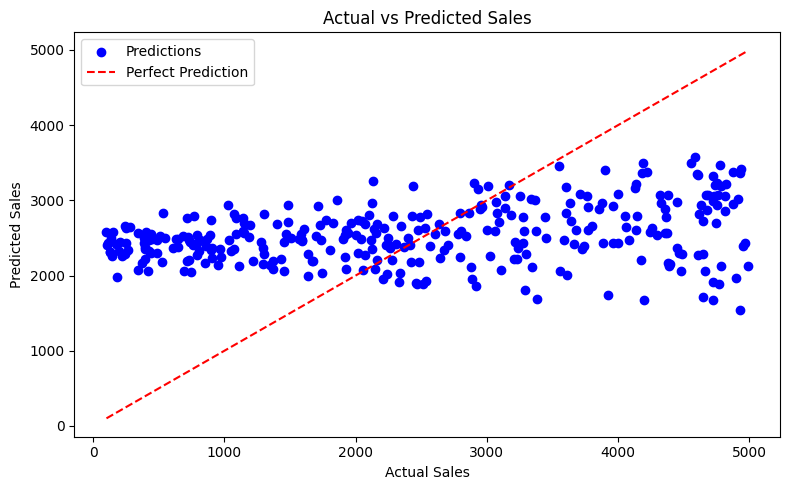

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Scatter points
plt.scatter(y_test, y_pred, color='blue', label='Predictions')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
#We try decision tree
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Decision Tree Results:")
print("MAE:", mean_absolute_error(y_test, tree_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tree_pred)))
print("R2 Score:", r2_score(y_test, tree_pred))

Decision Tree Results:
MAE: 922.1164099206717
RMSE: 1111.3912777741953
R2 Score: 0.4467965590930161


In [24]:
#We try Random forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results:
MAE: 916.9079986353847
RMSE: 1107.7930045179694
R2 Score: 0.45037289590742724


Python was used to perform exploratory data analysis and build predictive models for sales. First, the dataset was loaded with pandas and inspected to understand its structure, data types, summary statistics, missing values, and duplicate records. The analysis showed that the dataset was already clean, with no missing values or duplicate rows, which reduced the need for preprocessing.

Data was transformed for analysis and modeling. The Order_Date column was converted to datetime format, and new features such as Year and Month were extracted. Grouping and aggregation operations were applied to analyze sales and profit across categories, countries, and customer segments, helping reveal business patterns beyond the Tableau dashboards.

For the machine learning stage, scikit-learn were used to predict sales. Categorical variables were encoded, the data was split into training and testing sets, and three models were evaluated: Linear Regression, Decision Tree, and Random Forest. Model performance was assessed using MAE, RMSE, and R² score. The Random forest model performed best.

The analysis shows that Electronics is the top-performing category due to high demand and value, while regions like Australia, Canada, and UAE present strong growth potential despite currently lower profits. Key factors influencing sales include category, customer segment (with Home Office leading), location, discounts, and time trends. Based on these insights, the business should focus on high-performing categories, expand into emerging regions, target the Home Office segment, optimize discount strategies, and enhance predictive models with more features to improve forecasting accuracy and decision-making.